# EDA: `ds_hr_regrid` vs ECMWF IFS

This notebook compares a regridded high-resolution reference (`ds_hr_regrid`) against the native ECMWF IFS low-resolution input (`ds_lr`).

In [1]:
import os

os.chdir("../../../")
print(f"CWD: {os.getcwd()}")

CWD: c:\Users\zharif\Documents\Dataset TA


In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [3]:
ds_hr = xr.open_zarr("data/era5_indonesia_2018-2022.zarr", consolidated=True)
ds_lr = xr.open_zarr("data/ifs_lowres_indonesia_2018-2022.zarr", consolidated=True)

print(ds_hr)
print(ds_lr)

<xarray.Dataset> Size: 4GB
Dimensions:                   (time: 7304, latitude: 181, longitude: 201)
Coordinates:
  * latitude                  (latitude) float32 724B 30.0 29.75 ... -15.0
  * longitude                 (longitude) float32 804B 90.0 90.25 ... 140.0
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 201), meta=np.ndarray>
    10m_v_component_of_wind   (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 201), meta=np.ndarray>
    2m_temperature            (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 201), meta=np.ndarray>
    total_precipitation_24hr  (time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 181, 201), meta=np.ndarray>
<xarray.Dataset> Size: 4GB
Dimensions:                   (time: 3652, prediction_timedelta: 61,
                               longitude: 41, lati

C:\Users\zharif\AppData\Local\Temp\ipykernel_23400\2406657024.py:2: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_lr = xr.open_zarr("data/ifs_lowres_indonesia_2018-2022.zarr", consolidated=True)


## Build `ds_hr_regrid`

Crop the ERA5 domain so it aligns perfectly with the IFS domain, then average each `6 x 6` high-resolution block onto the IFS grid.

In [4]:
scale = 6

ds_hr = ds_hr.sortby("latitude")
ds_lr = ds_lr.sortby("latitude")

tr_lons = ds_hr.longitude.values
tr_lats = ds_hr.latitude.values
fc_lons = ds_lr.longitude.values
fc_lats = ds_lr.latitude.values

valid_lons = fc_lons[(fc_lons >= tr_lons.min()) & (fc_lons <= tr_lons.max())]
valid_lats = fc_lats[(fc_lats >= tr_lats.min()) & (fc_lats <= tr_lats.max())]

lon_start = valid_lons[0]
lat_start = valid_lats[0]

lon_start_idx = int(np.argmin(np.abs(tr_lons - lon_start)))
lat_start_idx = int(np.argmin(np.abs(tr_lats - lat_start)))
fc_lon_start_idx = int(np.argmin(np.abs(fc_lons - lon_start)))
fc_lat_start_idx = int(np.argmin(np.abs(fc_lats - lat_start)))

avail_lon = len(tr_lons) - lon_start_idx
avail_lat = len(tr_lats) - lat_start_idx
max_fc_lon = min(avail_lon // scale, 32)
max_fc_lat = min(avail_lat // scale, 24)

ds_lr = ds_lr.isel(
    longitude=slice(fc_lon_start_idx, fc_lon_start_idx + max_fc_lon),
    latitude=slice(fc_lat_start_idx, fc_lat_start_idx + max_fc_lat),
)

low_lon = ds_lr.sizes["longitude"]
low_lat = ds_lr.sizes["latitude"]

ds_hr = ds_hr.isel(
    longitude=slice(lon_start_idx, lon_start_idx + low_lon * scale),
    latitude=slice(lat_start_idx, lat_start_idx + low_lat * scale),
)

common_vars = [var for var in ds_lr.data_vars if var in ds_hr.data_vars]
ds_hr = ds_hr[common_vars]
ds_lr = ds_lr[common_vars]

ds_hr_regrid = (
    ds_hr.coarsen(latitude=scale, longitude=scale, boundary="trim")
    .mean()
    .assign_coords(latitude=ds_lr.latitude, longitude=ds_lr.longitude)
)

print("Common variables:", common_vars)
print("ds_lr shape:", {k: int(v) for k, v in ds_lr.sizes.items()})
print("ds_hr cropped shape:", {k: int(v) for k, v in ds_hr.sizes.items()})
print("ds_hr_regrid shape:", {k: int(v) for k, v in ds_hr_regrid.sizes.items()})

Common variables: ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'total_precipitation_24hr']
ds_lr shape: {'time': 3652, 'prediction_timedelta': 61, 'longitude': 32, 'latitude': 24}
ds_hr cropped shape: {'time': 7304, 'latitude': 144, 'longitude': 192}
ds_hr_regrid shape: {'time': 7304, 'latitude': 24, 'longitude': 32}


In [5]:
ds_hr_regrid

<xarray.Dataset> Size: 90MB
Dimensions:                   (time: 7304, latitude: 24, longitude: 32)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float64 192B -13.5 -12.0 ... 19.5 21.0
  * longitude                 (longitude) float64 256B 90.0 91.5 ... 135.0 136.5
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 22MB dask.array<chunksize=(1, 24, 32), meta=np.ndarray>
    10m_v_component_of_wind   (time, latitude, longitude) float32 22MB dask.array<chunksize=(1, 24, 32), meta=np.ndarray>
    2m_temperature            (time, latitude, longitude) float32 22MB dask.array<chunksize=(1, 24, 32), meta=np.ndarray>
    total_precipitation_24hr  (time, latitude, longitude) float32 22MB dask.array<chunksize=(1, 24, 32), meta=np.ndarray>

## Helper functions

In [13]:
VAR_ORDER = [
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_temperature",
    "total_precipitation_24hr",
]

FIELD_VMIN = [-6, -8, 285, 0.0]
FIELD_VMAX = [6, 8, 302, 0.025]
ERROR_LIM = [4, 4, 5, 0.015]
CMAPS_FIELD = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]


def _pick_coord_name(ds, candidates):
    for name in candidates:
        if name in ds.coords or name in ds.dims:
            return name
    return None


def _normalize_lon(lon, target):
    lon = np.asarray(lon)
    if lon.min() >= 0 and target < 0:
        return (target + 360) % 360
    if lon.max() <= 180 and target > 180:
        return ((target + 180) % 360) - 180
    return target


def _weekly_agg(series, var_name):
    if "precip" in var_name.lower() or "tp" in var_name.lower():
        return series.resample("W").sum(), "sum"
    return series.resample("W").mean(), "mean"


def _to_lat_lon(da, lat_name, lon_name):
    return da.squeeze().transpose(lat_name, lon_name).sortby(lat_name).sortby(lon_name)


def _lead_to_str(td):
    hours = int(pd.Timedelta(td).total_seconds() // 3600)
    if hours % 24 == 0:
        days = hours // 24
        return f"{days} day" if days == 1 else f"{days} days"
    return f"{hours} hours"

## Point comparison at Surabaya

Compare weekly aggregated valid-time series from `ds_hr_regrid` and ECMWF IFS at a fixed lead time.

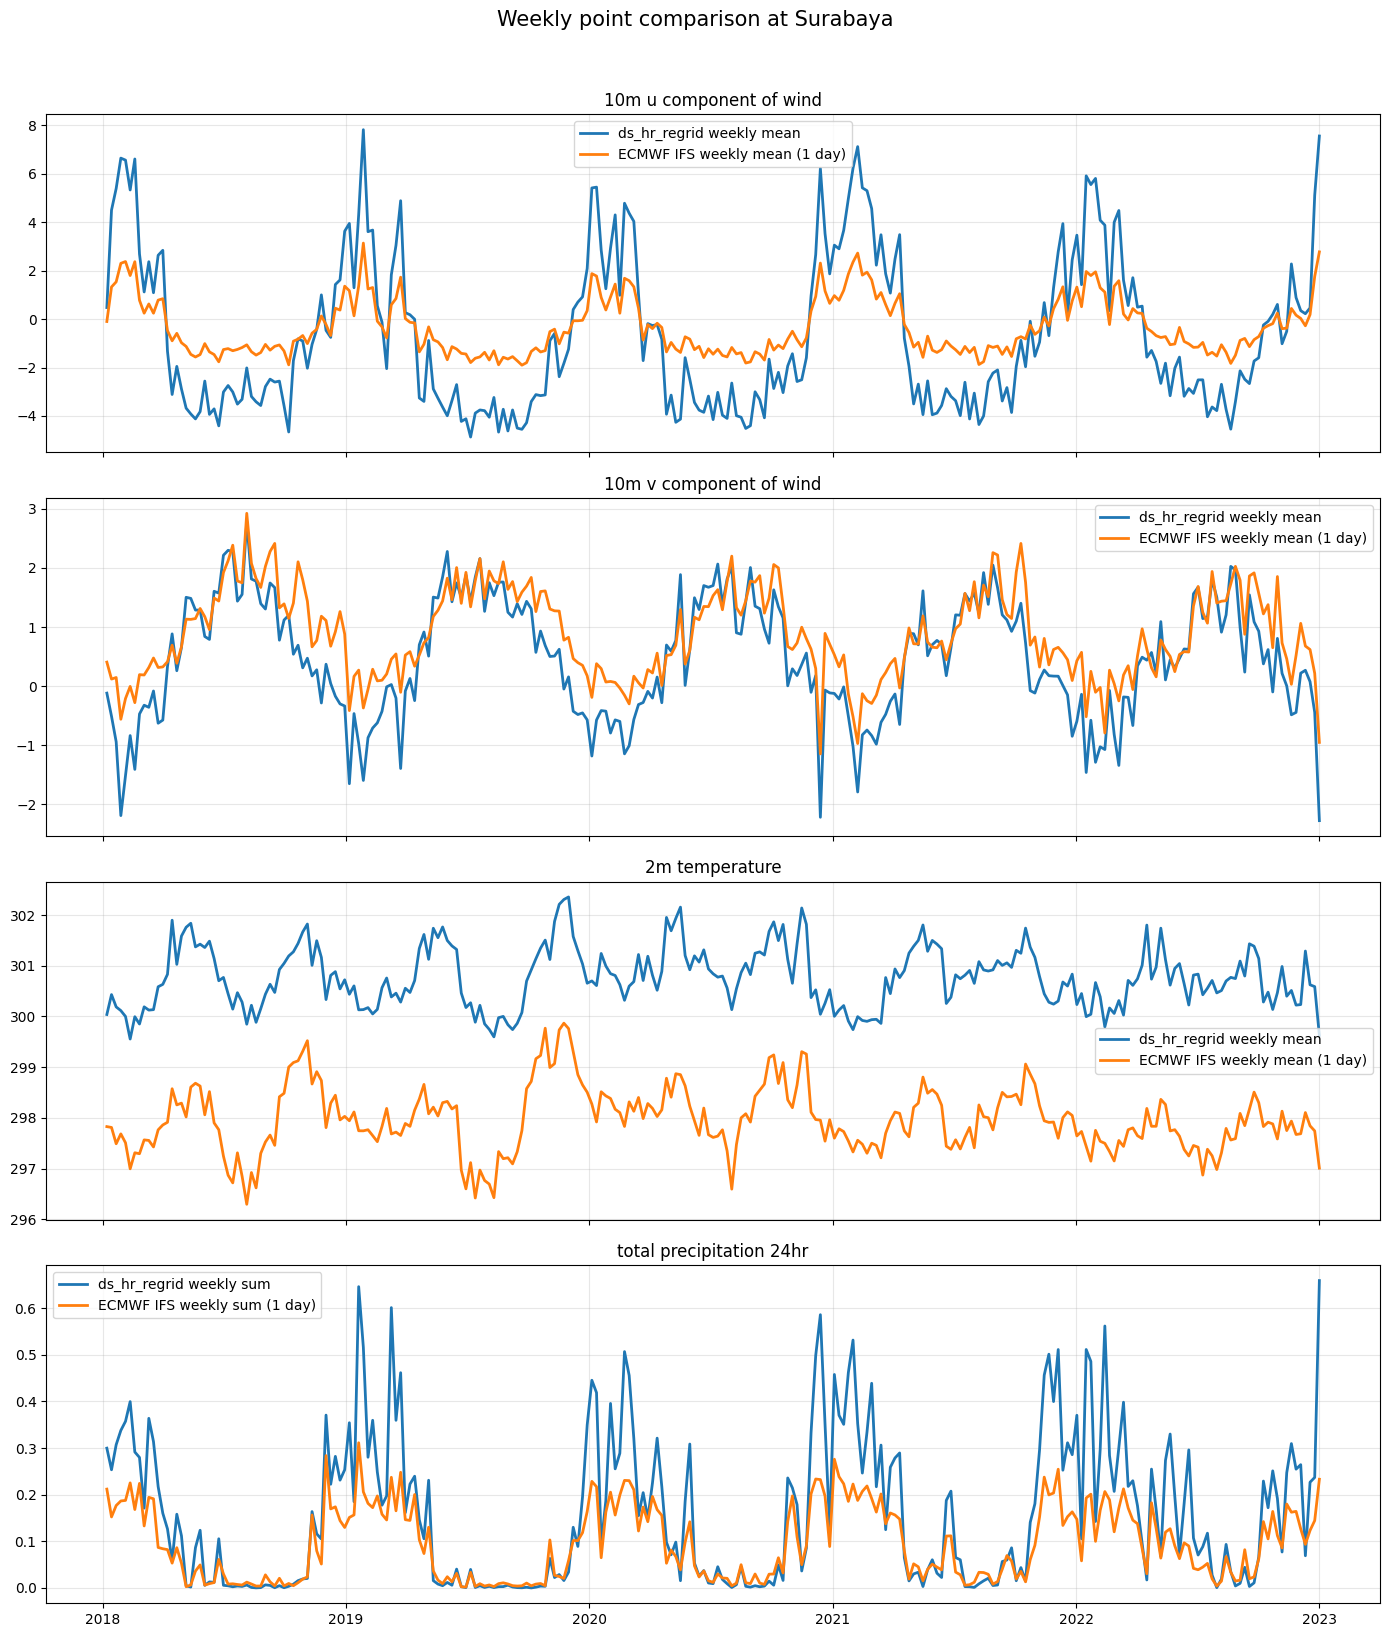

In [14]:
surabaya_lat = -7.2575
surabaya_lon = 112.7521
target_lead = pd.Timedelta(days=1)

lead_name = _pick_coord_name(ds_lr, ["prediction_timedelta", "step", "lead_time", "lead", "delta"])
time_name_lr = _pick_coord_name(ds_lr, ["time", "valid_time", "forecast_time", "datetime"])
time_name_hr = _pick_coord_name(ds_hr_regrid, ["time", "valid_time", "forecast_time", "datetime"])
lat_name_lr = _pick_coord_name(ds_lr, ["latitude", "lat", "y"])
lon_name_lr = _pick_coord_name(ds_lr, ["longitude", "lon", "x"])
lat_name_hr = _pick_coord_name(ds_hr_regrid, ["latitude", "lat", "y"])
lon_name_hr = _pick_coord_name(ds_hr_regrid, ["longitude", "lon", "x"])

lead_values = pd.to_timedelta(ds_lr[lead_name].values)
lead_matches = np.where(lead_values == target_lead)[0]
if len(lead_matches) == 0:
    available = ", ".join(str(v) for v in lead_values)
    raise ValueError(f"target_lead={target_lead} not found in '{lead_name}'. Available leads: {available}")
lead_idx = int(lead_matches[0])
lead_selected = lead_values[lead_idx]

sel_lon_lr = _normalize_lon(ds_lr[lon_name_lr].values, surabaya_lon)
sel_lon_hr = _normalize_lon(ds_hr_regrid[lon_name_hr].values, surabaya_lon)

plot_vars = [var for var in VAR_ORDER if var in ds_lr.data_vars and var in ds_hr_regrid.data_vars]
fig, axes = plt.subplots(len(plot_vars), 1, figsize=(14, 4 * len(plot_vars)), sharex=True)
axes = np.atleast_1d(axes)

for ax, var_name in zip(axes, plot_vars):
    lr_point = ds_lr[var_name].sel(
        {lat_name_lr: surabaya_lat, lon_name_lr: sel_lon_lr},
        method="nearest",
    ).sel({lead_name: lead_selected})

    hr_point = ds_hr_regrid[var_name].sel(
        {lat_name_hr: surabaya_lat, lon_name_hr: sel_lon_hr},
        method="nearest",
    )

    valid_times = pd.to_datetime(ds_lr[time_name_lr].values) + lead_selected
    lr_series = pd.Series(lr_point.values, index=pd.DatetimeIndex(valid_times), name="ifs")
    hr_series = pd.Series(hr_point.values, index=pd.DatetimeIndex(pd.to_datetime(ds_hr_regrid[time_name_hr].values)), name="ds_hr_regrid")

    if "precip" in var_name.lower() or "tp" in var_name.lower():
        lr_weekly = lr_series.resample("W").sum()
        lr_label = "sum"
    else:
        lr_weekly = lr_series.resample("W").mean()
        lr_label = "mean"
    hr_weekly, hr_label = _weekly_agg(hr_series, var_name)

    common_index = lr_weekly.index.intersection(hr_weekly.index)
    lr_plot = lr_weekly.loc[common_index]
    hr_plot = hr_weekly.loc[common_index]

    ax.plot(common_index, hr_plot, label=f"ds_hr_regrid weekly {hr_label}", linewidth=2)
    ax.plot(common_index, lr_plot, label=f"ECMWF IFS weekly {lr_label} ({_lead_to_str(lead_selected)})", linewidth=2)
    ax.set_title(var_name.replace("_", " "))
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Weekly point comparison at Surabaya", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

## Simple skill metrics at Surabaya

In [15]:
rows = []

for var_name in plot_vars:
    lr_point = ds_lr[var_name].sel(
        {lat_name_lr: surabaya_lat, lon_name_lr: sel_lon_lr},
        method="nearest",
    ).sel({lead_name: lead_selected})

    hr_point = ds_hr_regrid[var_name].sel(
        {lat_name_hr: surabaya_lat, lon_name_hr: sel_lon_hr},
        method="nearest",
    )

    lr_series = pd.Series(lr_point.values, index=pd.DatetimeIndex(pd.to_datetime(ds_lr[time_name_lr].values) + lead_selected))
    hr_series = pd.Series(hr_point.values, index=pd.DatetimeIndex(pd.to_datetime(ds_hr_regrid[time_name_hr].values)))

    common_index = lr_series.index.intersection(hr_series.index)
    comp = pd.DataFrame({
        "ifs": lr_series.loc[common_index],
        "ds_hr_regrid": hr_series.loc[common_index],
    }).dropna()

    if len(comp) == 0:
        continue

    diff = comp["ifs"] - comp["ds_hr_regrid"]
    rows.append({
        "variable": var_name,
        "n_samples": len(comp),
        "bias": float(diff.mean()),
        "mae": float(np.abs(diff).mean()),
        "rmse": float(np.sqrt(np.mean(diff ** 2))),
        "corr": float(comp["ifs"].corr(comp["ds_hr_regrid"])),
    })

metrics_df = pd.DataFrame(rows).sort_values("variable")
metrics_df

,variable,n_samples,bias,mae,rmse,corr
0,10m_u_component_of_wind,3649,0.435762,1.964494,2.302893,0.949362
1,10m_v_component_of_wind,3649,0.212678,0.868850,1.079517,0.694020
2,2m_temperature,3649,-2.591220,2.591220,2.657941,0.767789
3,total_precipitation_24hr,3649,0.001186,0.002743,0.004324,0.832038


## Full-domain map comparison

Compare ECMWF IFS and `ds_hr_regrid` on the same grid for rainy and dry season snapshots.

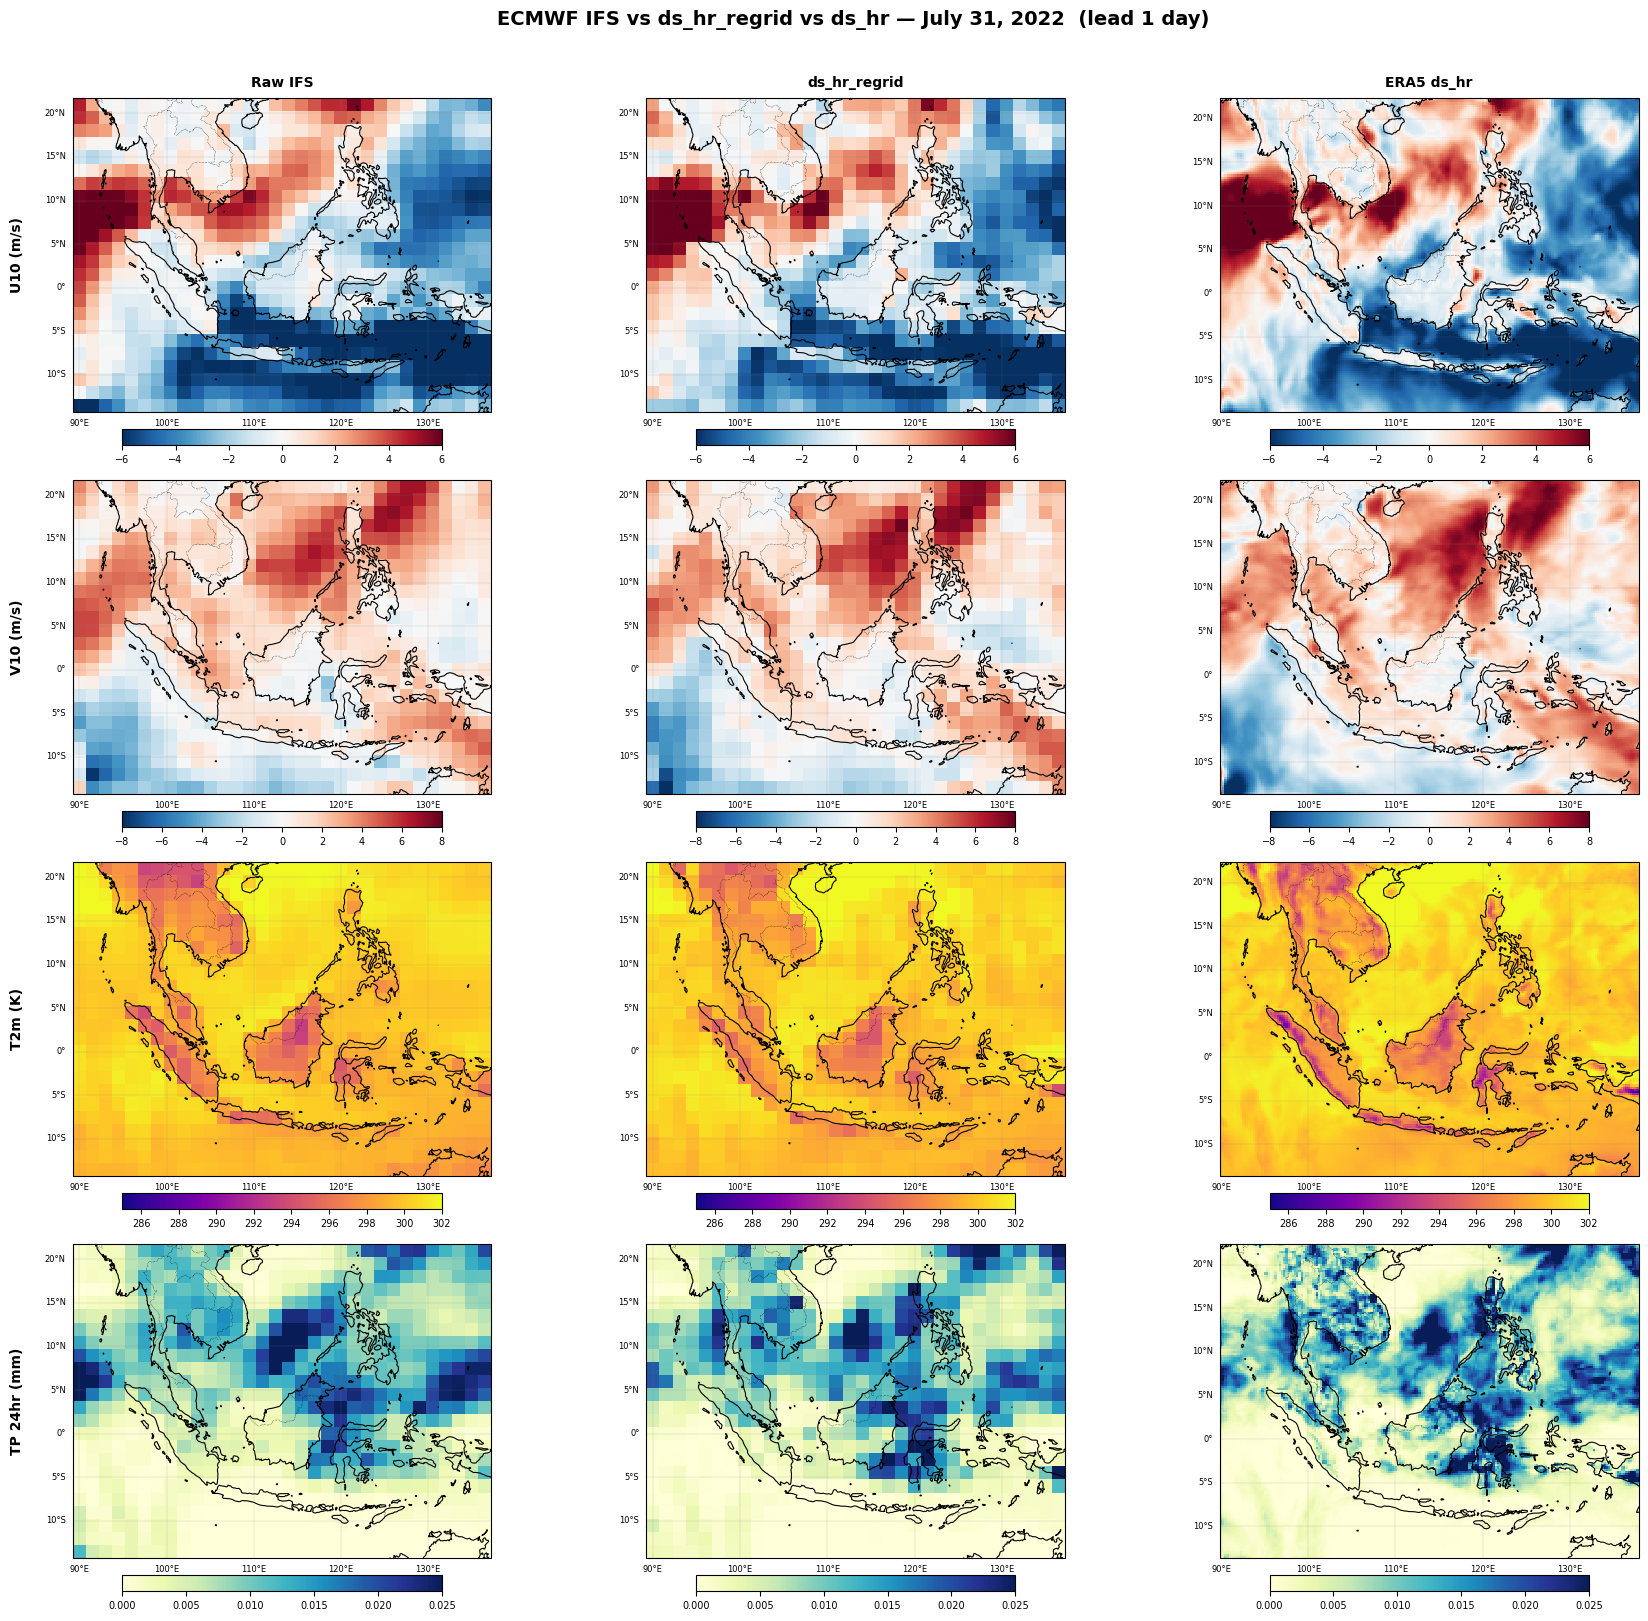

In [21]:
target_date = pd.Timestamp("2022-07-31")
season_label = "July 31, 2022"

VAR_LABELS_VIZ = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]
FIELD_VMIN = [-6, -8, 285, 0.0]
FIELD_VMAX = [6, 8, 302, 0.025]
ERROR_LIM = [4, 4, 5, 0.015]
CMAPS_FIELD = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]

proj = ccrs.PlateCarree()
lr_times = pd.to_datetime(ds_lr[time_name_lr].values)
hr_times = pd.to_datetime(ds_hr_regrid[time_name_hr].values)

init_idx = int(np.argmin(np.abs(lr_times - target_date)))
init_time = pd.Timestamp(lr_times[init_idx])
valid_time = init_time + lead_selected
hr_idx = int(np.argmin(np.abs(hr_times - valid_time)))
hr_time = pd.Timestamp(hr_times[hr_idx])

fig, axes = plt.subplots(len(plot_vars), 3, figsize=(18, 4 * len(plot_vars)), subplot_kw={"projection": proj})
axes = np.atleast_2d(axes)

for row_idx, var_name in enumerate(plot_vars):
    style_idx = VAR_ORDER.index(var_name)
    vmin = FIELD_VMIN[style_idx]
    vmax = FIELD_VMAX[style_idx]
    cmap = CMAPS_FIELD[style_idx]

    lr_field = _to_lat_lon(
        ds_lr[var_name].sel({time_name_lr: init_time, lead_name: lead_selected}, method="nearest"),
        lat_name_lr,
        lon_name_lr,
    )
    hr_regrid_field = _to_lat_lon(
        ds_hr_regrid[var_name].sel({time_name_hr: hr_time}, method="nearest"),
        lat_name_hr,
        lon_name_hr,
    )
    hr_field = _to_lat_lon(
        ds_hr[var_name].sel({time_name_hr: hr_time}, method="nearest"),
        lat_name_hr,
        lon_name_hr,
    )

    panels = [
        (lr_field, "ECMWF IFS", cmap, vmin, vmax),
        (hr_regrid_field, "ds_hr_regrid", cmap, vmin, vmax),
        (hr_field, "ERA5 ds_hr", cmap, vmin, vmax),
    ]

    for col_idx, (field, title, panel_cmap, panel_vmin, panel_vmax) in enumerate(panels):
        ax = axes[row_idx, col_idx]

        if field.shape != (len(field[lat_name_lr]), len(field[lon_name_lr])):
            field = field.transpose(lat_name_lr, lon_name_lr)

        mesh = ax.pcolormesh(
            field[lon_name_lr],
            field[lat_name_lr],
            field,
            transform=proj,
            shading="nearest",
            cmap=panel_cmap,
            vmin=panel_vmin,
            vmax=panel_vmax,
        )
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":")
        ax.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0)
        ax.add_feature(cfeature.OCEAN, facecolor="lightcyan", zorder=0)

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 6}
        gl.ylabel_style = {"size": 6}

        cb = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05, fraction=0.046)
        cb.ax.tick_params(labelsize=7)

        if row_idx == 0:
            ax.set_title(["Raw IFS", "ds_hr_regrid", "ERA5 ds_hr"][col_idx], fontsize=10, fontweight="bold", pad=8)
        if col_idx == 0:
            ax.text(-0.15, 0.5, VAR_LABELS_VIZ[row_idx], transform=ax.transAxes, fontsize=10, fontweight="bold", va="center", rotation=90)

fig.suptitle(
    f"ECMWF IFS vs ds_hr_regrid vs ds_hr — {season_label}  (lead {_lead_to_str(lead_selected)})",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

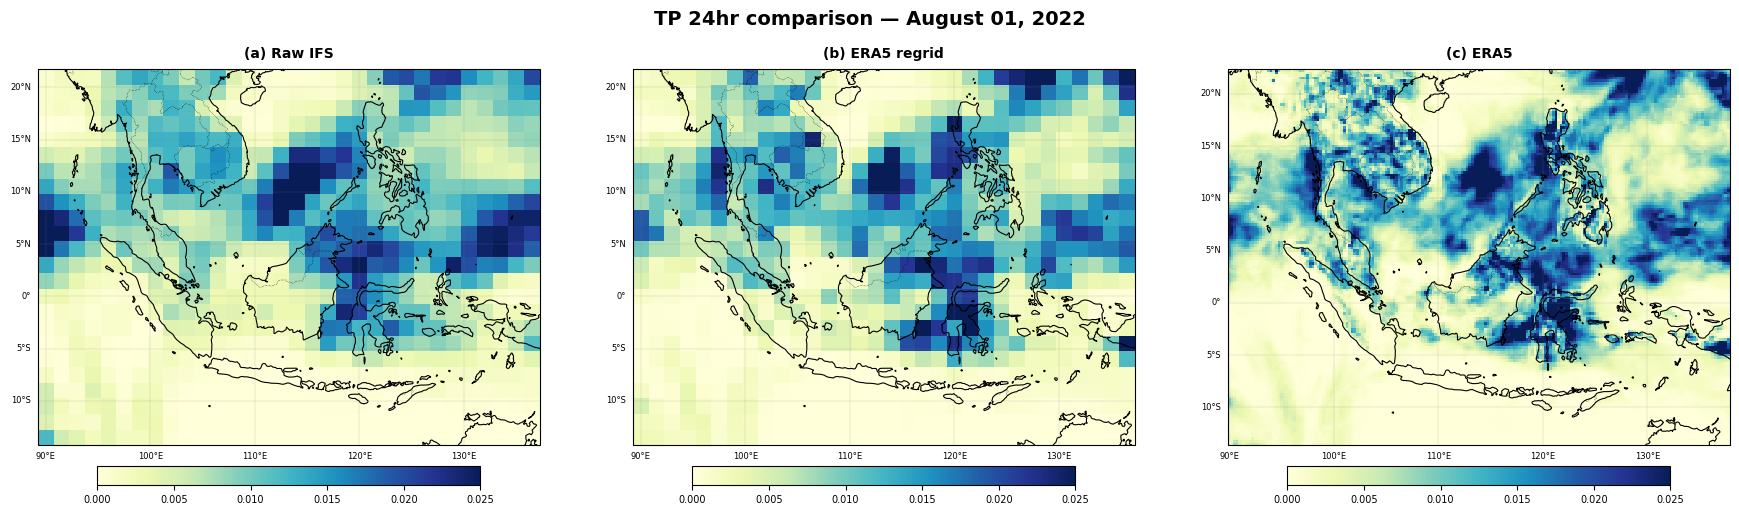

In [26]:
tp_var = "total_precipitation_24hr"

proj = ccrs.PlateCarree()
lr_times = pd.to_datetime(ds_lr[time_name_lr].values)
hr_times = pd.to_datetime(ds_hr_regrid[time_name_hr].values)

init_idx = int(np.argmin(np.abs(lr_times - target_date)))
init_time = pd.Timestamp(lr_times[init_idx])
valid_time = init_time + lead_selected
hr_idx = int(np.argmin(np.abs(hr_times - valid_time)))
hr_time = pd.Timestamp(hr_times[hr_idx])

lr_field = _to_lat_lon(
    ds_lr[tp_var].sel({time_name_lr: init_time, lead_name: lead_selected}, method="nearest"),
    lat_name_lr,
    lon_name_lr,
)
hr_regrid_field = _to_lat_lon(
    ds_hr_regrid[tp_var].sel({time_name_hr: hr_time}, method="nearest"),
    lat_name_hr,
    lon_name_hr,
)
hr_field = _to_lat_lon(
    ds_hr[tp_var].sel({time_name_hr: hr_time}, method="nearest"),
    lat_name_hr,
    lon_name_hr,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={"projection": proj})

panels = [
    (lr_field, "(a) Raw IFS", "YlGnBu", FIELD_VMIN[3], FIELD_VMAX[3]),
    (hr_regrid_field, "(b) ERA5 regrid", "YlGnBu", FIELD_VMIN[3], FIELD_VMAX[3]),
    (hr_field, "(c) ERA5", "YlGnBu", FIELD_VMIN[3], FIELD_VMAX[3]),
]

for ax, (field, title, panel_cmap, panel_vmin, panel_vmax) in zip(axes, panels):
    if field.shape != (len(field[lat_name_lr]), len(field[lon_name_lr])):
        field = field.transpose(lat_name_lr, lon_name_lr)

    mesh = ax.pcolormesh(
        field[lon_name_lr],
        field[lat_name_lr],
        field,
        transform=proj,
        shading="nearest",
        cmap=panel_cmap,
        vmin=panel_vmin,
        vmax=panel_vmax,
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="lightcyan", zorder=0)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 6}
    gl.ylabel_style = {"size": 6}

    cb = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05, fraction=0.046)
    cb.ax.tick_params(labelsize=7)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)

fig.suptitle(
    f"TP 24hr comparison — August 01, 2022",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()